In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df=pd.read_csv("IRIS.csv")

In [4]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [8]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [9]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import math
import scipy.stats as stats
#Preprocessing
from sklearn.preprocessing import LabelEncoder , MinMaxScaler , QuantileTransformer , PowerTransformer
#Model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score , confusion_matrix
#Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [11]:
df.shape

(150, 5)

In [12]:
print(f"Null values = {df.isnull().sum()}")
# no null values 

Null values = sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


In [13]:
print(f"Duplicate Values = {df.duplicated().sum()}")
# 3 duplicates present in the dataset

Duplicate Values = 3


In [14]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [33]:
numeric_features=df.select_dtypes(include=["float64"]).columns
print(numeric_features)
for feature in numeric_features:
    print(f"Feature:{df[feature].name}")
    print(f"Mean:{df[feature].mean():.2f}")
    print(f"Median:{df[feature].median():.2f}")
    print(f"Standard Deviation:{df[feature].std():.2f}\n")

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width'], dtype='object')
Feature:sepal_length
Mean:5.84
Median:5.80
Standard Deviation:0.83

Feature:sepal_width
Mean:3.05
Median:3.00
Standard Deviation:0.43

Feature:petal_length
Mean:3.76
Median:4.35
Standard Deviation:1.76

Feature:petal_width
Mean:1.20
Median:1.30
Standard Deviation:0.76



In [35]:
df["species"].value_counts()
# perfectly balanced dataset

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

# Distribution Plots

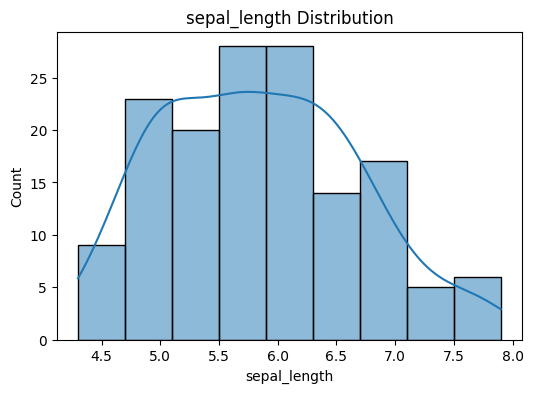

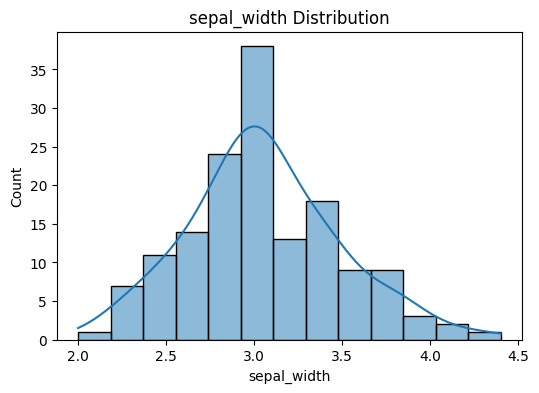

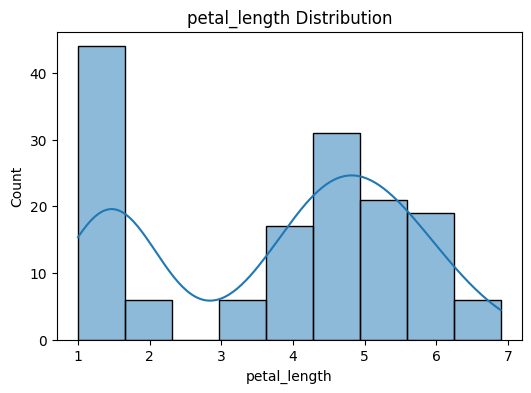

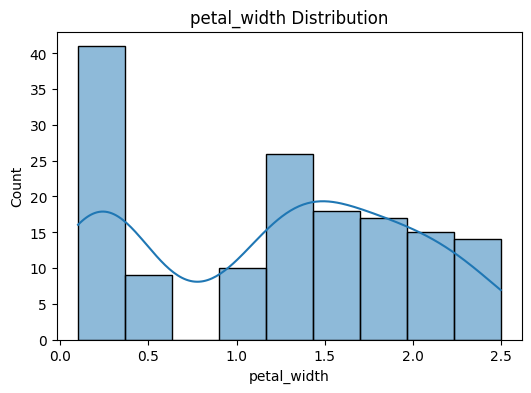

In [38]:
for feature in numeric_features:
    plt.figure(figsize=(6,4))
    sns.histplot(df[feature],kde=True)
    plt.title(f"{feature} Distribution")
    plt.show()

# Outlier Detection

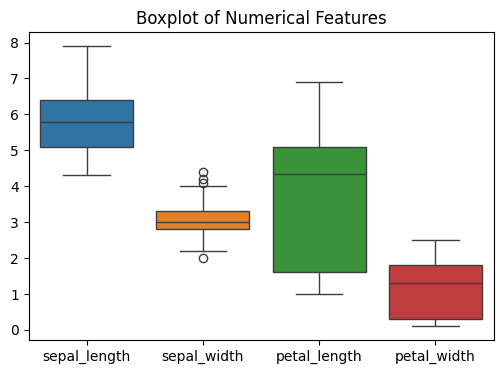

In [47]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df.drop(columns="species"))
plt.title("Boxplot of Numerical Features")
plt.show()

# Species-wise Feature Comparison

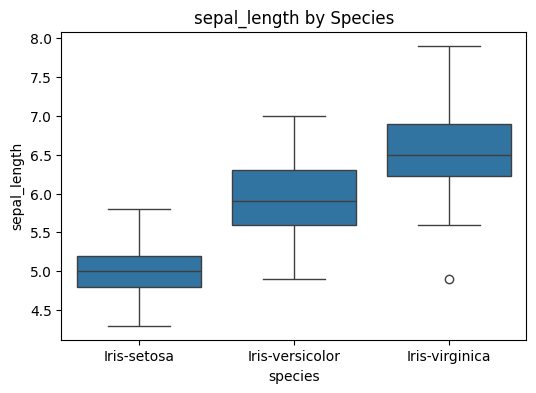

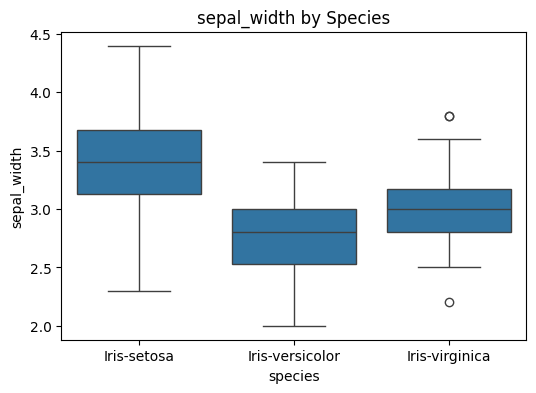

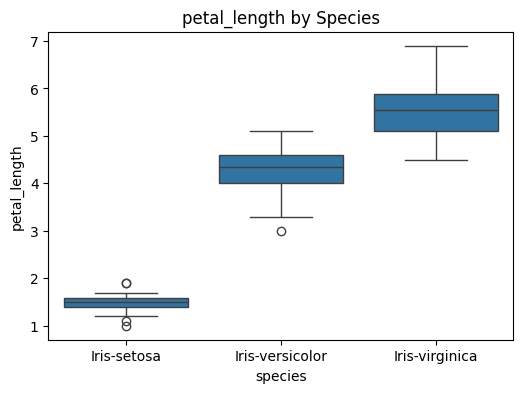

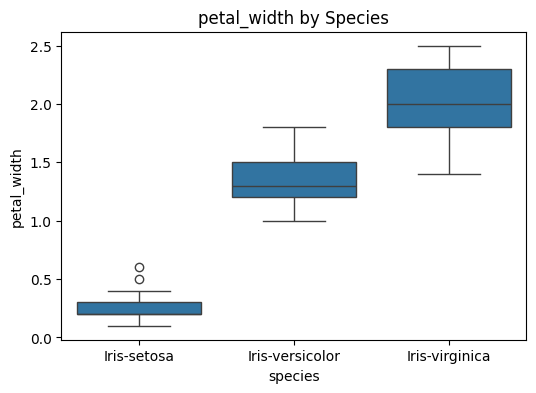

In [46]:
for feature in numeric_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='species', y=feature, data=df)
    plt.title(f"{feature} by Species")
    plt.show()
# setosa is completely separable 

# Scatter Plots

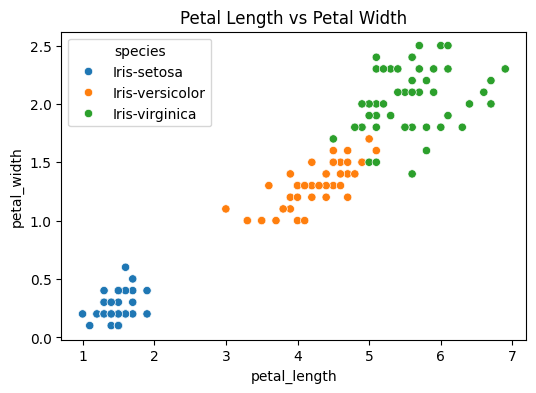

In [48]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='petal_length',y='petal_width', hue='species',data=df)
plt.title("Petal Length vs Petal Width")
plt.show()

# Pair Plots

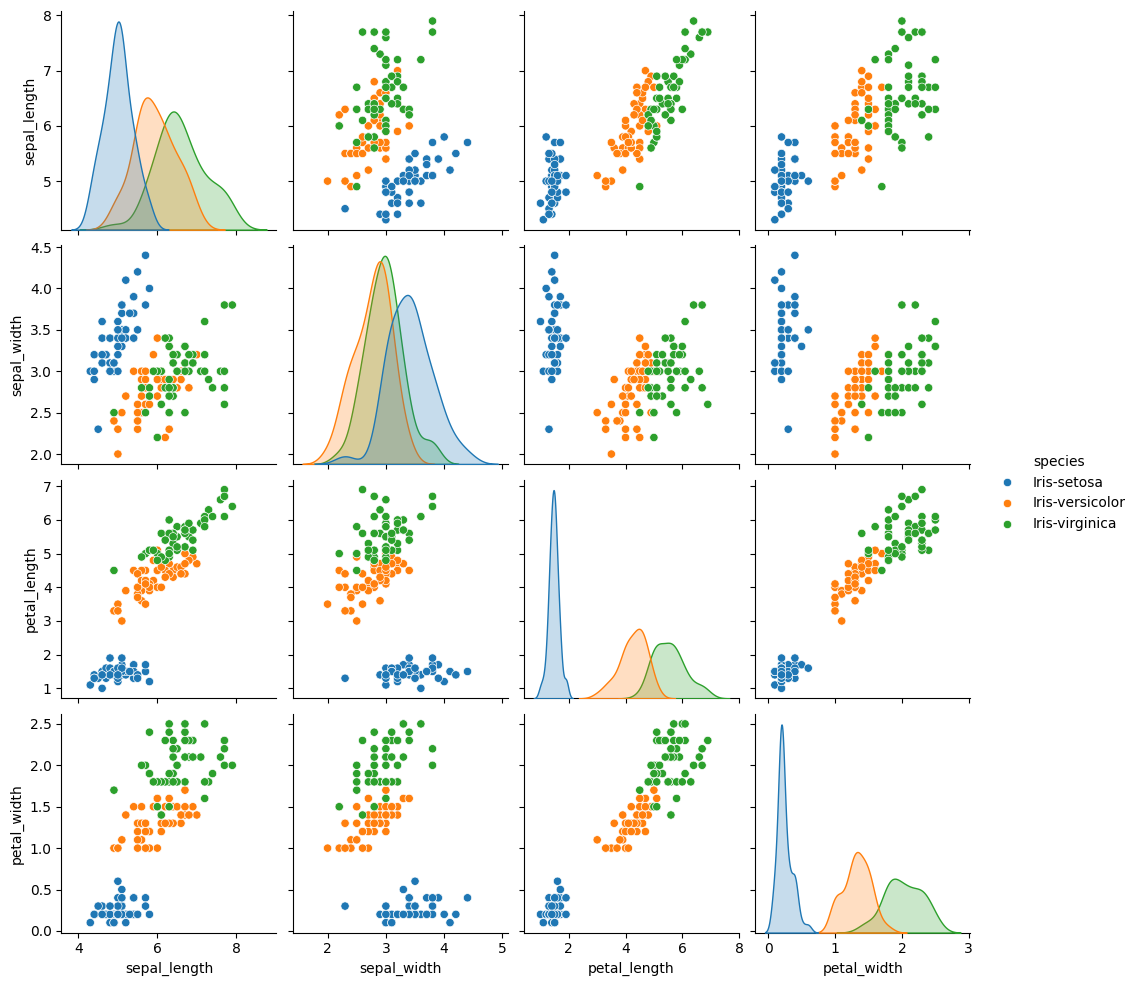

In [49]:
sns.pairplot(df,hue="species")
plt.show()

# Correlation Matrix

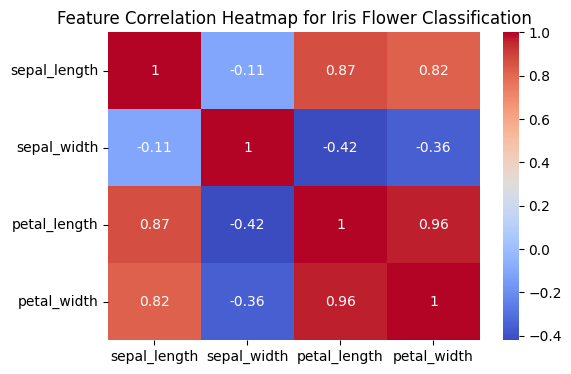

In [54]:
plt.figure(figsize=(6,4))
sns.heatmap(df.drop(columns="species").corr(),annot=True,cmap="coolwarm")
plt.title("Feature Correlation Heatmap for Iris Flower Classification")
plt.show()